<a href="https://colab.research.google.com/github/nameershah/unified-clinical-edge-ai/blob/main/unified_clinical_edge_ai_phase1_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unified Clinical Edge AI — Phase 1: Baseline Model Training

**Project:** unified-clinical-edge-ai  
**Author:** Muhammad Nameer Shah  
**Dataset:** PathMNIST (MedMNIST v2)  
**Model:** ResNet-18 (ImageNet pretrained, fine-tuned)  
**Task:** 9-class colorectal cancer tissue classification  
**Target:** Test Accuracy ≥ 90%, Macro AUC ≥ 0.97  

---

### Architecture Overview
This notebook trains a ResNet-18 classifier on PathMNIST clinical tissue patches. The trained model weights are exported for use in Phase 2 (H.E.A.R.L. edge quantization and deterministic routing).

**Pipeline:**
```
PathMNIST Data → ResNet-18 → Softmax Probabilities → Metrics (Acc, AUC, F1) → Export .pth
```

## Section 1: Install Dependencies

In [1]:
!pip install medmnist scikit-learn matplotlib seaborn -q
print("All dependencies installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 5.8 MB/s eta 0:00:00
All dependencies installed.


## Section 2: Imports & Device Configuration

All core libraries. GPU (T4) is auto-detected — runtime must be set to **GPU** in Colab.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models, transforms

import medmnist
from medmnist import PathMNIST

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    accuracy_score
)

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"MedMNIST version: {medmnist.__version__}")

Device: cuda
MedMNIST version: 3.0.2


## Section 3: Hyperparameters & Configuration

All tunable parameters in one place for reproducibility.

In [3]:
# ── Hyperparameters ──────────────────────────────────────────────────────────
BATCH_SIZE  = 64
EPOCHS      = 15
LR          = 1e-3
NUM_CLASSES = 9       # PathMNIST: 9 colorectal tissue types
SEED        = 42
IMG_SIZE    = 28      # PathMNIST native resolution (upsampled to 224 for ResNet)

# Reproducibility
torch.manual_seed(SEED)
np.random.seed(SEED)

# PathMNIST class labels
CLASS_LABELS = [
    "Adipose", "Background", "Debris", "Lymphocytes",
    "Mucus", "Smooth Muscle", "Normal Colon Mucosa",
    "Cancer-Assoc. Stroma", "Colorectal Adenocarcinoma"
]

print(f"Classes: {NUM_CLASSES} | Epochs: {EPOCHS} | Batch: {BATCH_SIZE} | LR: {LR}")

Classes: 9 | Epochs: 15 | Batch: 64 | LR: 0.001


## Section 4: Data Loading — PathMNIST

PathMNIST is a colorectal cancer histology patch dataset (100K images, 28×28 RGB).  
Images are resized to 224×224 to match ResNet-18's expected input. Normalization uses ImageNet statistics since we're fine-tuning a pretrained model.

100%|██████████| 206M/206M [01:41<00:00, 2.02MB/s]


Train: 89,996 | Val: 10,004 | Test: 7,180


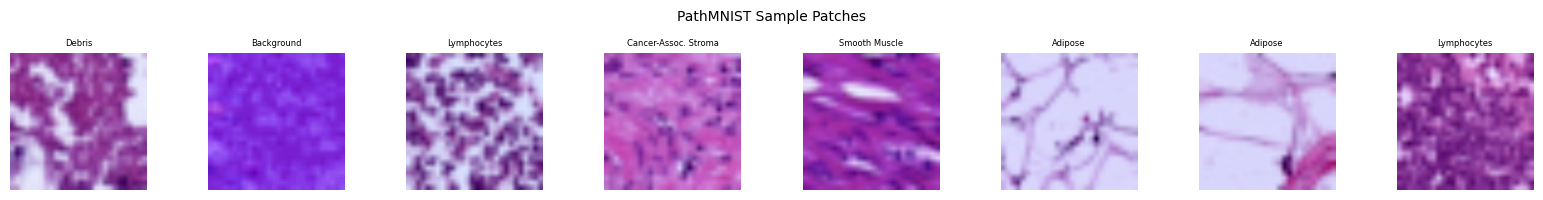

In [4]:
# Transforms: resize to 224x224, normalize to ImageNet stats
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Download and load datasets
train_dataset = PathMNIST(split='train', transform=train_transform, download=True, as_rgb=True)
val_dataset   = PathMNIST(split='val',   transform=eval_transform,  download=True, as_rgb=True)
test_dataset  = PathMNIST(split='test',  transform=eval_transform,  download=True, as_rgb=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_dataset):,} | Val: {len(val_dataset):,} | Test: {len(test_dataset):,}")

# Visualize sample patches
imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i, ax in enumerate(axes):
    img = imgs[i].permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min())  # denormalize for display
    ax.imshow(img)
    ax.set_title(CLASS_LABELS[labels[i].item()], fontsize=6)
    ax.axis('off')
plt.suptitle("PathMNIST Sample Patches", fontsize=10)
plt.tight_layout()
plt.savefig("sample_patches.png", dpi=150, bbox_inches='tight')
plt.show()

## Section 5: Model Definition — ResNet-18

ResNet-18 pretrained on ImageNet. The final fully-connected layer is replaced with a 9-class head. The backbone is fully fine-tuned (all layers unfrozen).

In [5]:
def build_model(num_classes: int) -> nn.Module:
    """
    Build ResNet-18 with a custom classification head.
    All backbone layers are trainable (full fine-tuning).
    """
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # Replace the final FC layer
    in_features = model.fc.in_features       # 512 for ResNet-18
    model.fc = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, num_classes)
    )
    return model


model     = build_model(NUM_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,} | Trainable: {trainable_params:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 198MB/s]


Total params: 11,181,129 | Trainable: 11,181,129


## Section 6: Training & Validation Loop

Standard PyTorch training loop with per-epoch loss and accuracy tracking. Best model (lowest val loss) is checkpointed automatically.

In [7]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    """Run one training epoch. Returns (avg_loss, accuracy)."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs   = imgs.to(device)
        labels = labels.squeeze().long().to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    """Evaluate on val/test. Returns (avg_loss, accuracy, preds, labels, probs)."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs   = imgs.to(device)
            labels = labels.squeeze().long().to(device)

            outputs = model(imgs)
            probs   = torch.softmax(outputs, dim=1)
            loss    = criterion(outputs, labels)

            total_loss += loss.item() * imgs.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += imgs.size(0)

            all_preds.extend(outputs.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return (
        total_loss / total,
        correct / total,
        np.array(all_preds),
        np.array(all_labels),
        np.array(all_probs)
    )

In [8]:
# ── Training Loop ─────────────────────────────────────────────────────────────
os.makedirs("exports", exist_ok=True)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss = float("inf")

print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>7}")
print("-" * 55)

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss, val_acc, _, _, _ = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "exports/resnet18_pathmnist_best.pth")
        best_marker = " ← best"
    else:
        best_marker = ""

    print(f"{epoch:>5} | {train_loss:>10.4f} | {train_acc:>9.4f} | {val_loss:>8.4f} | {val_acc:>7.4f}{best_marker}")

print("\nTraining complete.")

Epoch | Train Loss | Train Acc | Val Loss | Val Acc
-------------------------------------------------------
    1 |     0.3058 |    0.8956 |   0.7546 |  0.7858 ← best
    2 |     0.1943 |    0.9357 |   0.1855 |  0.9416 ← best
    3 |     0.1593 |    0.9475 |   0.1682 |  0.9452 ← best
    4 |     0.1365 |    0.9545 |   0.1183 |  0.9630 ← best
    5 |     0.1176 |    0.9614 |   0.0805 |  0.9738 ← best
    6 |     0.0988 |    0.9676 |   0.0908 |  0.9707
    7 |     0.0885 |    0.9706 |   0.0911 |  0.9682
    8 |     0.0738 |    0.9753 |   0.0693 |  0.9768 ← best
    9 |     0.0636 |    0.9795 |   0.0482 |  0.9847 ← best
   10 |     0.0521 |    0.9832 |   0.0354 |  0.9892 ← best
   11 |     0.0408 |    0.9868 |   0.0341 |  0.9891 ← best
   12 |     0.0338 |    0.9889 |   0.0287 |  0.9920 ← best
   13 |     0.0257 |    0.9917 |   0.0260 |  0.9924 ← best
   14 |     0.0219 |    0.9930 |   0.0208 |  0.9942 ← best
   15 |     0.0195 |    0.9941 |   0.0217 |  0.9933

Training complete.


## Section 7: Test Set Evaluation & Metrics

Load best checkpoint and evaluate on the held-out test set. Reports accuracy, macro AUC, and per-class F1.

In [9]:
# Load best model
model.load_state_dict(torch.load("exports/resnet18_pathmnist_best.pth", map_location=DEVICE))

_, test_acc, test_preds, test_labels, test_probs = evaluate(
    model, test_loader, criterion, DEVICE
)

# Metrics
macro_auc = roc_auc_score(test_labels, test_probs, multi_class='ovr', average='macro')

print(f"Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"Macro AUC     : {macro_auc:.4f}")
print()
print("Per-Class Report:")
print(classification_report(test_labels, test_preds, target_names=CLASS_LABELS))

# Save metrics
metrics = {
    "test_accuracy" : round(float(test_acc),    4),
    "macro_auc"     : round(float(macro_auc),   4),
    "model"         : "ResNet-18",
    "dataset"       : "PathMNIST",
    "epochs"        : EPOCHS,
    "num_classes"   : NUM_CLASSES,
    "class_labels"  : CLASS_LABELS,
    "training_history": history
}

with open("exports/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Metrics saved to exports/metrics.json")

Test Accuracy : 0.9221  (92.21%)
Macro AUC     : 0.9861

Per-Class Report:
                           precision    recall  f1-score   support

                  Adipose       0.97      0.93      0.95      1338
               Background       0.94      1.00      0.97       847
                   Debris       0.88      0.79      0.83       339
              Lymphocytes       0.96      1.00      0.98       634
                    Mucus       0.94      0.91      0.93      1035
            Smooth Muscle       0.69      0.88      0.77       592
      Normal Colon Mucosa       0.94      0.98      0.96       741
     Cancer-Assoc. Stroma       0.94      0.60      0.73       421
Colorectal Adenocarcinoma       0.96      0.96      0.96      1233

                 accuracy                           0.92      7180
                macro avg       0.91      0.89      0.90      7180
             weighted avg       0.93      0.92      0.92      7180

Metrics saved to exports/metrics.json


## Section 8: Visualizations

Training curves and confusion matrix saved as PNGs for the paper and README.

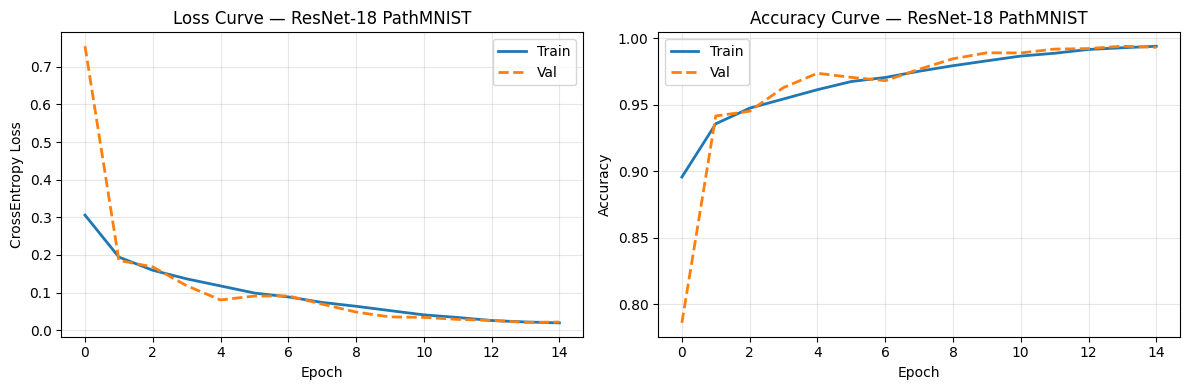

Saved: exports/training_curves.png


In [10]:
# Training Curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="Train", linewidth=2)
axes[0].plot(history["val_loss"],   label="Val",   linewidth=2, linestyle="--")
axes[0].set_title("Loss Curve — ResNet-18 PathMNIST")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("CrossEntropy Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history["train_acc"], label="Train", linewidth=2)
axes[1].plot(history["val_acc"],   label="Val",   linewidth=2, linestyle="--")
axes[1].set_title("Accuracy Curve — ResNet-18 PathMNIST")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("exports/training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: exports/training_curves.png")

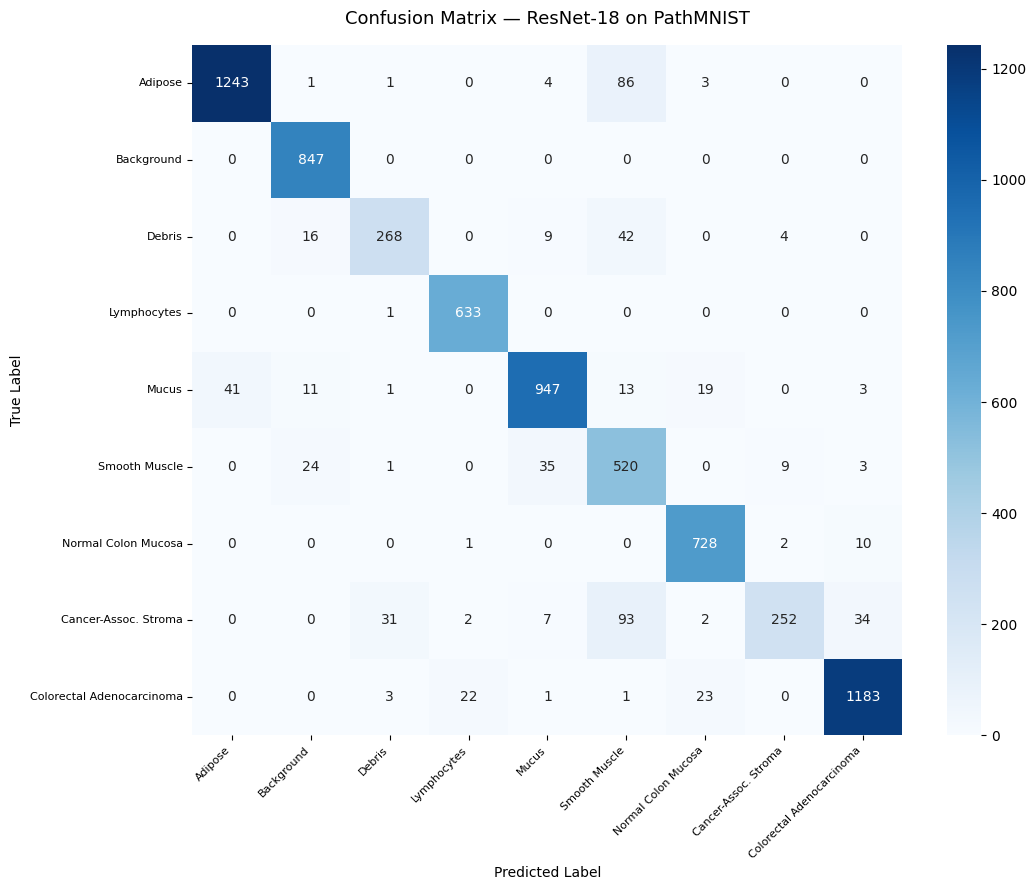

Saved: exports/confusion_matrix.png


In [11]:
# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(11, 9))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_LABELS,
    yticklabels=CLASS_LABELS
)
plt.title("Confusion Matrix — ResNet-18 on PathMNIST", fontsize=13, pad=15)
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("exports/confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: exports/confusion_matrix.png")

## Section 9: Export Model Weights

Two exports:
- `resnet18_pathmnist_best.pth` — model weights only (for inference/deployment)
- `checkpoint_full.pth` — full checkpoint including optimizer state (for resuming training)

In [12]:
# Full checkpoint (for resuming or Phase 2 fine-tuning)
torch.save({
    "epoch"              : EPOCHS,
    "model_state_dict"   : model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "best_val_loss"      : best_val_loss,
    "metrics"            : metrics,
    "class_labels"       : CLASS_LABELS,
    "num_classes"        : NUM_CLASSES
}, "exports/checkpoint_full.pth")

print("Exports:")
for f in os.listdir("exports"):
    size = os.path.getsize(f"exports/{f}") / 1024
    print(f"  exports/{f:45s}  {size:8.1f} KB")

print(f"""
─────────────────────────────────────────────
Phase 1 Complete
─────────────────────────────────────────────
Test Accuracy  : {test_acc*100:.2f}%
Macro AUC      : {macro_auc:.4f}
─────────────────────────────────────────────
Next → Download exports/ folder → Phase 2
         Edge Quantization + H.E.A.R.L. Routing
""")

Exports:
  exports/metrics.json                                        2.0 KB
  exports/checkpoint_full.pth                            131161.4 KB
  exports/resnet18_pathmnist_best.pth                     43755.8 KB
  exports/confusion_matrix.png                              130.2 KB
  exports/training_curves.png                                79.8 KB

─────────────────────────────────────────────
Phase 1 Complete
─────────────────────────────────────────────
Test Accuracy  : 92.21%
Macro AUC      : 0.9861
─────────────────────────────────────────────
Next → Download exports/ folder → Phase 2
         Edge Quantization + H.E.A.R.L. Routing

